In [60]:
import matplotlib.pyplot as plt
import numpy as np

In [45]:
import subprocess
import json

def run_bench(n: int, runs: int = 100) -> dict:
    cmd = ["cargo", "run", "--profile", "fast", "--bin", "bench", "--", str(n), str(runs)]
    result = subprocess.run(cmd, capture_output=True, text=True, cwd="../../wasm")
    result.check_returncode()
    return json.loads(result.stdout)


In [72]:
ns_to_plot = list(range(6, 21))
all_data = {n: run_bench(n, runs=200) for n in ns_to_plot}

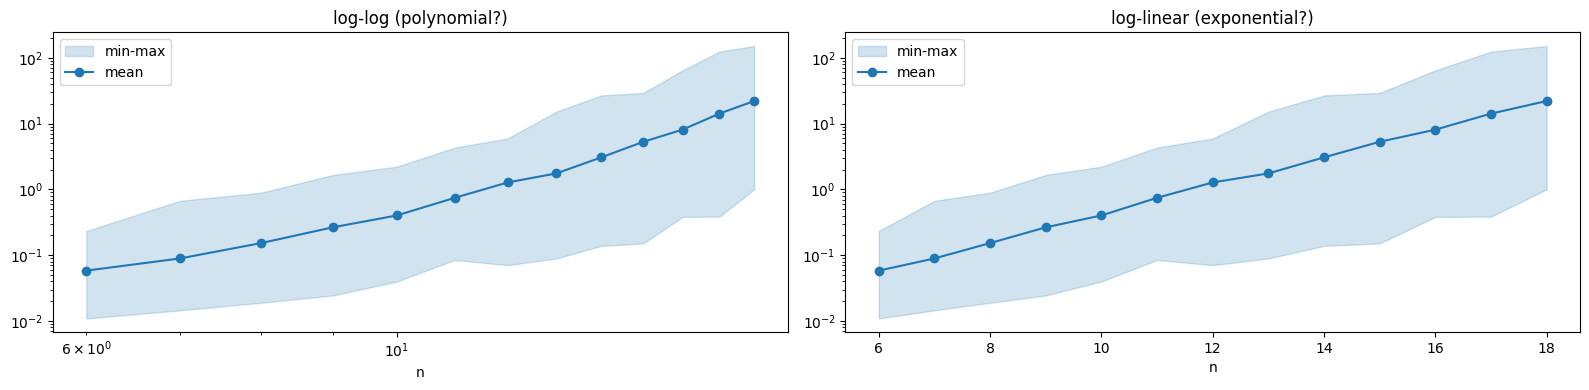

R² log-log  (polynomial):   0.9788  →  O(n^5.49)
R² log-lin  (exponential):  0.9992  →  ~1.646x per +1 n
verdict: exponential


In [ ]:
from scipy import stats

ns = np.array(ns_to_plot, dtype=float)
means = np.array([np.mean(all_data[n]["ms"]) for n in ns_to_plot])
lows = np.array([np.min(all_data[n]["ms"]) for n in ns_to_plot])
highs = np.array([np.max(all_data[n]["ms"]) for n in ns_to_plot])

# plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# log-log (straight = polynomial)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.fill_between(ns, lows, highs, alpha=0.2, color="tab:blue", label="min-max")
ax1.plot(ns, means, marker="o", color="tab:blue", label="mean")
ax1.set_xlabel("n")
ax1.set_title("log-log (polynomial?)")
ax1.legend()

# log-linear (straight = exponential)
ax2.set_yscale("log")
ax2.fill_between(ns, lows, highs, alpha=0.2, color="tab:blue", label="min-max")
ax2.plot(ns, means, marker="o", color="tab:blue", label="mean")
ax2.set_xlabel("n")
ax2.set_title("log-linear (exponential?)")
ax2.legend()

plt.tight_layout()
plt.show()

# big-O
log_ns, log_means = np.log(ns), np.log(means)

r2_poly = stats.pearsonr(log_ns, log_means).statistic ** 2
r2_exp = stats.pearsonr(ns, log_means).statistic ** 2

poly_slope, _ = np.polyfit(log_ns, log_means, 1)
exp_slope, _ = np.polyfit(ns, log_means, 1)

verdict = "exponential" if r2_exp > r2_poly else "polynomial"
print(f"R² log-log  (polynomial):   {r2_poly:.4f}  →  O(n^{poly_slope:.2f})")
print(
    f"R² log-lin  (exponential):  {r2_exp:.4f}  →  ~{np.exp(exp_slope):.3f}x per +1 n"
)
print(f"verdict: {verdict}")

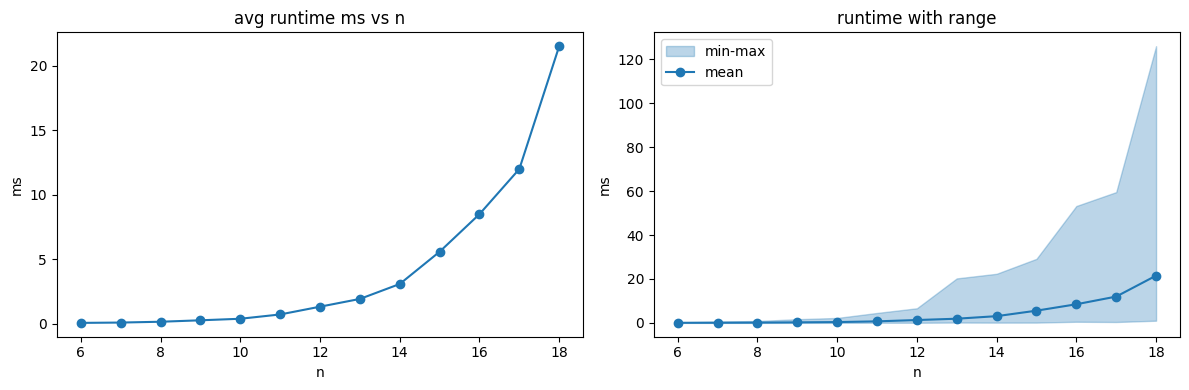

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

means = np.array([np.mean(all_data[n]["ms"]) for n in ns_to_plot])
lows  = np.array([np.min(all_data[n]["ms"])  for n in ns_to_plot])
highs = np.array([np.max(all_data[n]["ms"])  for n in ns_to_plot])

ax1.plot(ns_to_plot, means, marker="o")
ax1.set_xlabel("n"); ax1.set_ylabel("ms"); ax1.set_title("avg runtime ms vs n")

ax2.fill_between(ns_to_plot, lows, highs, alpha=0.3, color="tab:blue", label="min-max")
ax2.plot(ns_to_plot, means, marker="o", color="tab:blue", label="mean")
ax2.set_xlabel("n"); ax2.set_ylabel("ms"); ax2.set_title("runtime with range")
ax2.legend()

plt.tight_layout()
plt.show()

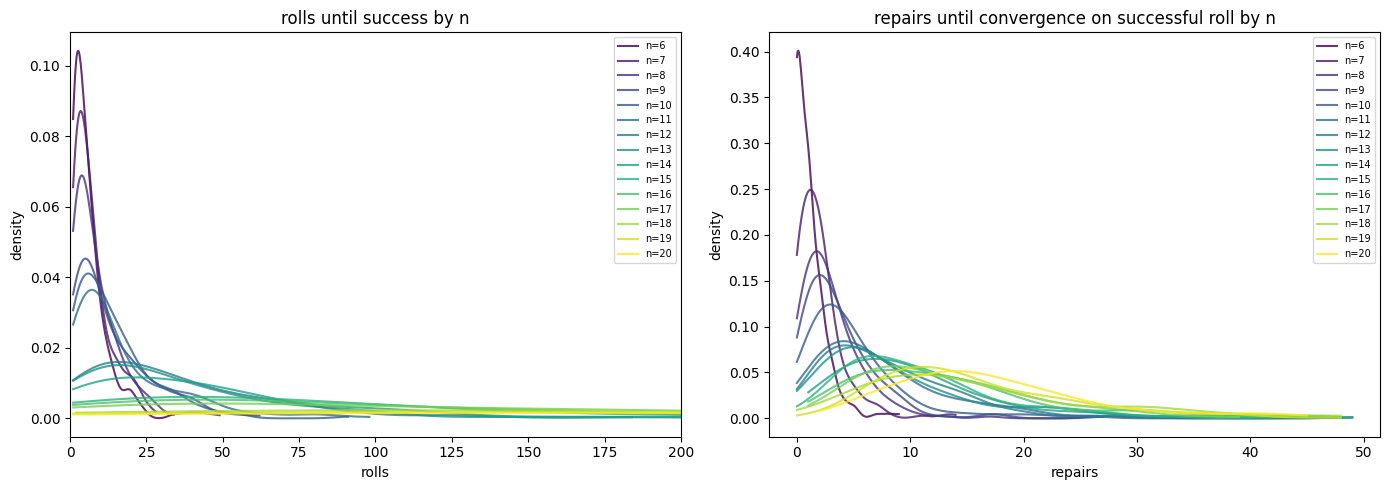

In [73]:
from scipy.stats import gaussian_kde

palette = plt.cm.viridis(np.linspace(0, 1, len(ns_to_plot)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for color, n in zip(palette, ns_to_plot):
    for ax, key in [(ax1, "rolls"), (ax2, "success_repairs")]:
        vals = np.array(all_data[n][key], dtype=float)
        if vals.std() == 0:
            continue
        kde = gaussian_kde(vals)
        xs = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(xs, kde(xs), color=color, alpha=0.8, label=f"n={n}")

ax1.set_xlabel("rolls"); ax1.set_ylabel("density")
ax1.set_xlim(left=0, right=200)
ax1.set_title("rolls until success by n")
ax1.legend(fontsize=7)

ax2.set_xlabel("repairs"); ax2.set_ylabel("density")
ax2.set_title("repairs until convergence on successful roll by n")
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

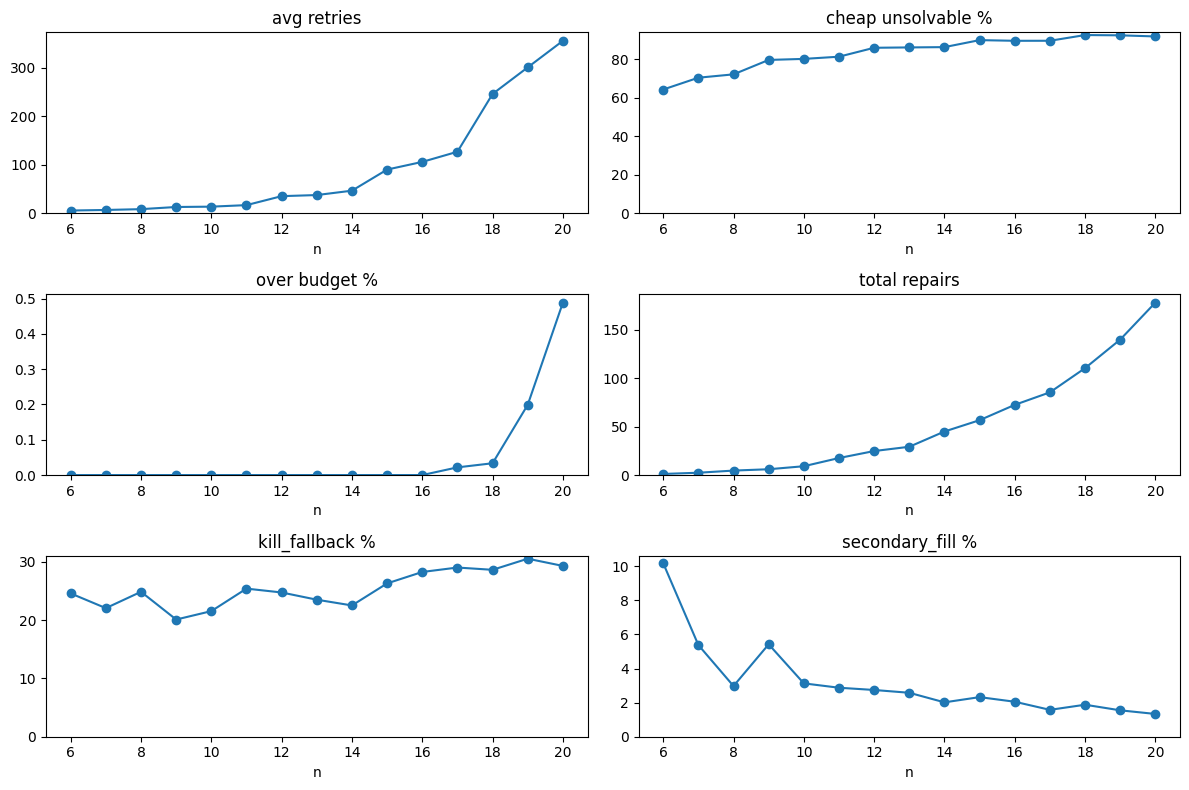

In [64]:
def avg(n, key):
    return np.mean(all_data[n][key])


def pct(n, key, denom_key):
    return 100.0 * np.sum(all_data[n][key]) / np.sum(all_data[n][denom_key])


keys_fns = [
    ("avg retries", lambda n: avg(n, "rolls")),
    ("cheap unsolvable %", lambda n: pct(n, "unsolvable", "rolls")),
    ("over budget %", lambda n: pct(n, "over_budget", "solves")),
    ("total repairs", lambda n: avg(n, "repairs")),
    ("kill_fallback %", lambda n: pct(n, "kill_fallback", "repairs")),
    ("secondary_fill %", lambda n: pct(n, "secondary_fills", "rolls"))
]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for ax, (title, fn) in zip(axes.flat, keys_fns):
    ax.plot(ns_to_plot, [fn(n) for n in ns_to_plot], marker="o")
    ax.set_xlabel("n")
    ax.set_title(title)
    ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

fit: 0.13 * e^(0.4510 * n)


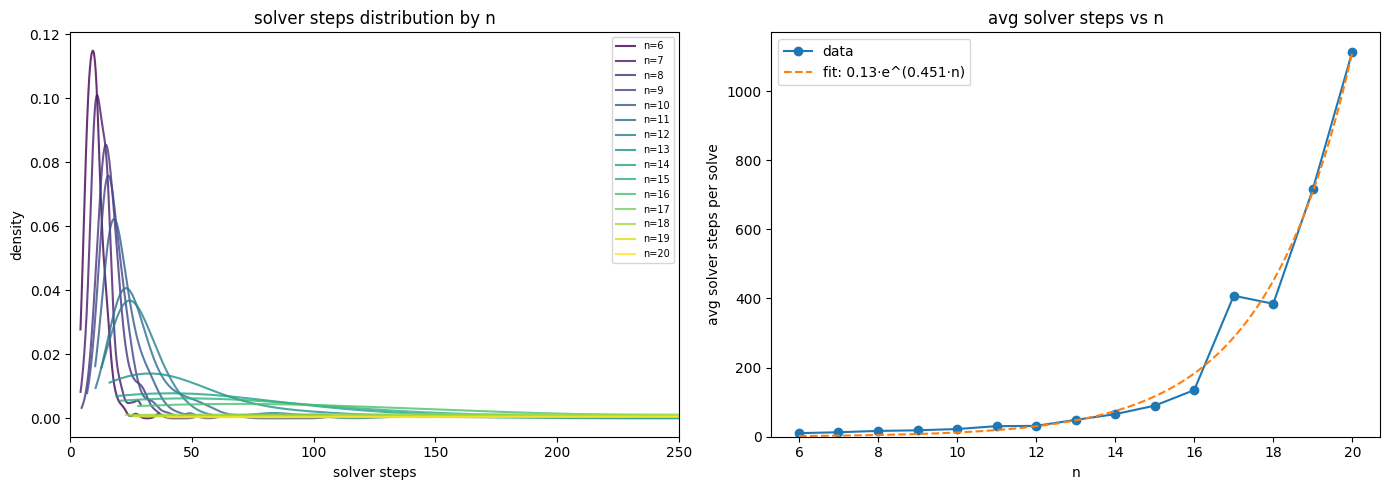

In [74]:
from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

palette = plt.cm.viridis(np.linspace(0, 1, len(ns_to_plot)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for color, n in zip(palette, ns_to_plot):
    steps = np.array(all_data[n]["solver_steps"], dtype=float)
    solves = np.array(all_data[n]["solves"], dtype=float)
    vals = steps / solves
    if vals.std() == 0:
        continue
    kde = gaussian_kde(vals)
    xs = np.linspace(vals.min(), vals.max(), 200)
    ax1.plot(xs, kde(xs), color=color, alpha=0.8, label=f"n={n}")

ax1.set_xlabel("solver steps")
ax1.set_ylabel("density")
ax1.set_title("solver steps distribution by n")
ax1.set_xlim(left=0, right=250)
ax1.legend(fontsize=7)

avg_steps = [np.mean(np.array(all_data[n]["solver_steps"]) / np.array(all_data[n]["solves"])) for n in ns_to_plot]

def exp_model(x, a, b):
    return a * np.exp(b * x)

popt, _ = curve_fit(exp_model, ns_to_plot, avg_steps, p0=[1, 0.1])
a, b = popt

ns_smooth = np.linspace(min(ns_to_plot), max(ns_to_plot), 200)
ax2.plot(ns_to_plot, avg_steps, marker="o", color="tab:blue", label="data")
ax2.plot(ns_smooth, exp_model(ns_smooth, a, b), "--", color="tab:orange", label=f"fit: {a:.2f}·e^({b:.3f}·n)")
ax2.set_xlabel("n")
ax2.set_ylabel("avg solver steps per solve")
ax2.set_title("avg solver steps vs n")
ax2.set_ylim(bottom=0)
ax2.legend()

print(f"fit: {a:.2f} * e^({b:.4f} * n)")

plt.tight_layout()
plt.show()

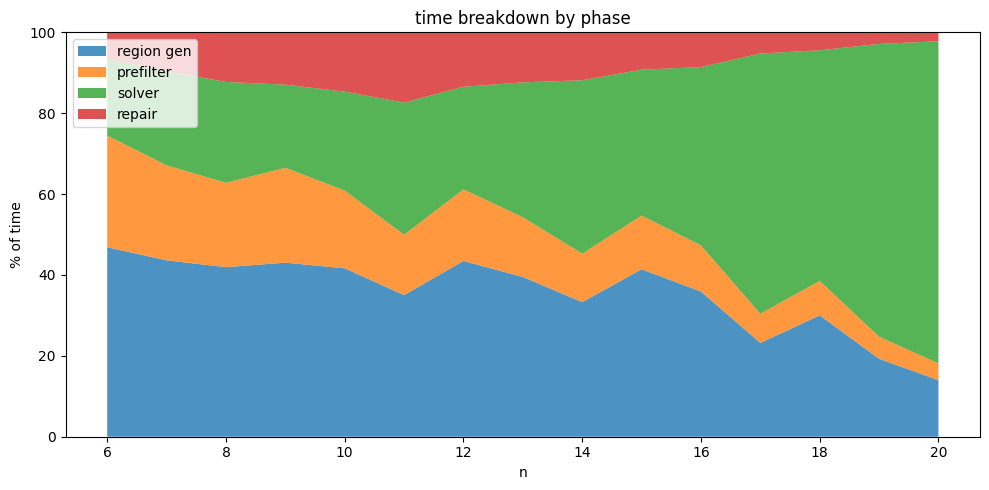

In [75]:
phases = ["t_regions", "t_solvable", "t_solve", "t_kill"]
labels = ["region gen", "prefilter", "solver", "repair"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# compute each phase as % of total t_* time per n
pcts = []
for phase in phases:
    vals = []
    for n in ns_to_plot:
        total = sum(np.mean(all_data[n][p]) for p in phases)
        vals.append(100.0 * np.mean(all_data[n][phase]) / total)
    pcts.append(vals)

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(ns_to_plot, pcts, labels=labels, colors=colors, alpha=0.8)
ax.set_xlabel("n")
ax.set_ylabel("% of time")
ax.set_title("time breakdown by phase")
ax.set_ylim(0, 100)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [76]:
print("Breakdown")
print(f"{'n':>4}  {'avg_ms':>10}  {'min_ms':>10}  {'max_ms':>10}")
print("-" * 40)
for n in ns_to_plot:
    ms = all_data[n]["ms"]
    print(f"{n:>4}  {np.mean(ms):>9.2f}ms  {np.min(ms):>9.2f}ms  {np.max(ms):>9.2f}ms")


Breakdown
   n      avg_ms      min_ms      max_ms
----------------------------------------
   6       0.05ms       0.01ms       0.20ms
   7       0.09ms       0.01ms       0.85ms
   8       0.15ms       0.02ms       0.86ms
   9       0.27ms       0.03ms       1.75ms
  10       0.38ms       0.04ms       2.16ms
  11       0.68ms       0.08ms       4.28ms
  12       1.32ms       0.09ms       6.00ms
  13       1.75ms       0.09ms      14.91ms
  14       3.10ms       0.13ms      26.10ms
  15       5.21ms       0.13ms      27.17ms
  16       8.47ms       0.38ms      64.35ms
  17      15.03ms       0.41ms     125.16ms
  18      23.49ms       0.88ms     153.32ms
  19      43.43ms       0.92ms     411.93ms
  20     113.83ms       1.89ms     854.69ms


In [77]:
with open("baseline.json") as f:
    baseline_data = json.load(f)

print("Baseline")
print(f"{'n':>4}  {'avg_ms':>10}  {'min_ms':>10}  {'max_ms':>10}")
print("-" * 40)
for n in ns_to_plot:
    ms = np.array(baseline_data[str(n)]["ms"])
    print(f"{n:>4}  {np.mean(ms):>9.2f}ms  {np.min(ms):>9.2f}ms  {np.max(ms):>9.2f}ms")

Baseline
   n      avg_ms      min_ms      max_ms
----------------------------------------
   6       0.05ms       0.01ms       0.19ms
   7       0.09ms       0.01ms       0.65ms
   8       0.16ms       0.02ms       1.08ms
   9       0.28ms       0.02ms       1.57ms
  10       0.37ms       0.04ms       2.34ms
  11       0.81ms       0.08ms       6.96ms
  12       1.40ms       0.07ms       7.54ms
  13       1.75ms       0.09ms      15.14ms
  14       4.04ms       0.19ms      32.26ms
  15       8.56ms       0.26ms      56.17ms
  16       9.29ms       0.39ms      67.44ms
  17      15.49ms       0.50ms     112.22ms
  18      25.16ms       0.94ms     219.00ms
  19      43.39ms       0.88ms     411.52ms
  20      74.53ms       1.26ms     451.16ms


In [80]:
print(f"{'n':>4}  {'baseline':>10}  {'current':>10}  {'change':>8}  {'p-value':>10}  conclusion")
print("-" * 72)

alpha = 0.01

for n in ns_to_plot:
    if str(n) not in baseline_data:
        continue
    a = np.array(baseline_data[str(n)]["ms"])
    b = np.array(all_data[n]["ms"])
    _, p = scipy_stats.mannwhitneyu(a, b, alternative="two-sided")
    change = 100 * (np.mean(b) - np.mean(a)) / np.mean(a)
    sig = "✓ significant" if p < alpha else "~ no change"
    direction = ("faster" if change < 0 else "slower") if p < alpha else ""
    print(f"{n:>4}  {np.mean(a):>9.2f}ms  {np.mean(b):>9.2f}ms  {change:>+7.1f}%  {p:>10.4f}  {sig} {direction}")


   n    baseline     current    change     p-value  conclusion
------------------------------------------------------------------------
   6       0.05ms       0.05ms     +3.3%      0.6786  ~ no change 
   7       0.09ms       0.09ms     +4.7%      0.6607  ~ no change 
   8       0.16ms       0.15ms     -7.3%      0.4612  ~ no change 
   9       0.28ms       0.27ms     -2.7%      0.8467  ~ no change 
  10       0.37ms       0.38ms     +2.7%      0.6321  ~ no change 
  11       0.81ms       0.68ms    -16.2%      0.1749  ~ no change 
  12       1.40ms       1.32ms     -5.4%      0.9490  ~ no change 
  13       1.75ms       1.75ms     +0.3%      0.8450  ~ no change 
  14       4.04ms       3.10ms    -23.2%      0.0321  ~ no change 
  15       8.56ms       5.21ms    -39.1%      0.0001  ✓ significant faster
  16       9.29ms       8.47ms     -8.9%      0.3364  ~ no change 
  17      15.49ms      15.03ms     -3.0%      0.7558  ~ no change 
  18      25.16ms      23.49ms     -6.6%      0.6005

In [69]:
confirm = input("Save current all_data as baseline? (y/N): ").strip().lower()
if confirm == "y":
    with open("baseline.json", "w") as f:
        json.dump({str(n): all_data[n] for n in ns_to_plot}, f)
    print("Saved.")
else:
    print("Aborted.")

Saved.
